# Etapa 2 — Modelagem com Redes Neurais (PyTorch) e Ensembles

**Requisitos atendidos neste notebook (conforme Tech Challenge PDF):**

| Requisito do PDF | Onde é atendido |
|---|---|
| MLP em PyTorch com arquitetura, função de ativação e loss function | Célula 4 |
| Loop de treinamento com early stopping e batching | Célula 5 |
| Comparar MLP vs baselines usando ≥ 4 métricas | Célula 8 |
| Analisar trade-off de custo (FP vs FN) | Célula 11 |
| Registrar todos os experimentos no MLflow | Célula 8 |
| Seeds fixados para reprodutibilidade | Célula 1 |
| Logging estruturado (sem print() nos módulos src/) | Todo o notebook |

> **Papel do notebook:** exploração, visualização e demonstração das decisões técnicas.  
> A lógica reutilizável (MLP, pipeline) vive em `src/` — o notebook consome, não duplica.

---
## Célula 1 — Imports e configuração

**Requisito PDF:** *Seeds fixados para reprodutibilidade.*  
**Requisito PDF:** *Logging estruturado (sem `print()`).*  

- `SEED = 42` é fixado em todas as bibliotecas (PyTorch, NumPy) antes de qualquer operação aleatória.
- O `PROJECT_ROOT` aponta para a raiz do projeto (`churn-prediction-pipeline/`) independente de onde o Jupyter foi aberto.
- Importamos de `src/` para não duplicar lógica — o notebook não reimplementa limpeza nem pipeline.

In [4]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import mlflow
import mlflow.pytorch
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

# --- Localização do projeto ---
# Path(os.getcwd()) aponta para notebooks/ — .parent sobe para a raiz do projeto.
# .resolve() converte para caminho absoluto real (necessário no Windows com drive F:\).
PROJECT_ROOT = Path(os.getcwd()).resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- Imports do projeto ---
# ATENÇÃO: o arquivo é logger.py, não logging.py
# (logging é módulo built-in do Python — usar o mesmo nome causa conflito)
from src.utils.logger import get_logger
from src.data.loader import load_raw, clean
from src.features.pipeline import build_preprocessor, prepare_features

logger = get_logger("etapa2_notebook")

# --- Seeds fixados — requisito obrigatório do Tech Challenge ---
# Garante que qualquer execução do notebook produza os mesmos resultados.
# Sem isso, o modelo muda a cada treino, impossibilitando comparação justa.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

logger.info("Imports OK. SEED=%d | PyTorch=%s | PROJECT_ROOT=%s", SEED, torch.__version__, PROJECT_ROOT)

2026-04-23 23:26:26 | INFO     | etapa2_notebook | Imports OK. SEED=42 | PyTorch=2.11.0+cpu | PROJECT_ROOT=F:\churn-prediction-pipeline


INFO:etapa2_notebook:Imports OK. SEED=42 | PyTorch=2.11.0+cpu | PROJECT_ROOT=F:\churn-prediction-pipeline


---
## Célula 2 — Carregamento e pré-processamento via `src/`

**Requisito PDF:** *Pipeline reprodutível (sklearn + transformadores custom).*  
**Requisito PDF:** *Validação cruzada estratificada* (aplicada aqui via `stratify=y`).

### Por que não usar `pd.get_dummies` aqui?
O `pd.get_dummies` é cômodo para exploração rápida (usado na Etapa 1 nos baselines),  
mas tem um problema crítico para produção: **não é serializável**.  
Quando a API receber um cliente novo, ela não tem o DataFrame original para rodar `get_dummies`.  
O `ColumnTransformer` do Scikit-Learn resolve isso: fazemos `fit` no treino, salvamos com `joblib`,  
e a API faz `transform` nos dados novos com as mesmas colunas e escala.

### O que é data leakage e por que evitar?
`fit_transform` no treino e só `transform` no val/test garante que a média e desvio padrão
usados para escalar os dados vêm **apenas do conjunto de treino** — como seria em produção real.

In [5]:
# 1. Carrega e limpa via módulos do projeto (sem duplicar lógica aqui)
df_raw = load_raw(PROJECT_ROOT / "data" / "raw" / "telco_churn.csv")
df = clean(df_raw)

logger.info("Dataset shape: %s | Taxa de churn: %.2f%%", df.shape, df['Churn'].mean() * 100)

# 2. Separa features (X) e target (y)
X, y = prepare_features(df)

# 3. Splits estratificados
# stratify=y garante que a proporção de churn (~26%) seja mantida em todos os splits.
# Sem isso, um split poderia ter 10% de churn e outro 40%, tornando a comparação inválida.
#
# Divisão final: 70% treino | 10% validação | 20% teste
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=SEED, stratify=y_trainval
)  # 0.125 * 80% = 10% do total

logger.info("Splits — treino: %d | val: %d | teste: %d", len(X_train), len(X_val), len(X_test))

# 4. Pré-processamento com ColumnTransformer
# - StandardScaler nas numéricas: centraliza em 0 e normaliza variância
# - OneHotEncoder nas categóricas: converte texto em colunas binárias (0/1)
# - fit APENAS no treino → transform no val e test (evita data leakage)
preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train).astype(np.float32)  # aprende a escala aqui
X_val_t   = preprocessor.transform(X_val).astype(np.float32)        # só aplica
X_test_t  = preprocessor.transform(X_test).astype(np.float32)       # só aplica

y_train_arr = y_train.values.astype(np.float32)
y_val_arr   = y_val.values.astype(np.float32)
y_test_arr  = y_test.values.astype(np.float32)

INPUT_DIM = X_train_t.shape[1]
logger.info("Dimensão de entrada para a MLP: %d features", INPUT_DIM)

2026-04-23 23:26:35 | INFO     | src.data.loader | Carregando dataset de F:\churn-prediction-pipeline\data\raw\telco_churn.csv


INFO:src.data.loader:Carregando dataset de F:\churn-prediction-pipeline\data\raw\telco_churn.csv


2026-04-23 23:26:35 | INFO     | src.data.loader | Shape bruto: (7043, 21)


INFO:src.data.loader:Shape bruto: (7043, 21)


2026-04-23 23:26:35 | INFO     | src.data.loader | Limpeza OK. Shape: (7043, 20) | Churn rate: 26.5%


...

INFO:src.features.pipeline:Features: (7043, 19) | Target: (7043,)


2026-04-23 23:26:35 | INFO     | etapa2_notebook | Splits — treino: 4929 | val: 705 | teste: 1409


INFO:etapa2_notebook:Splits — treino: 4929 | val: 705 | teste: 1409


2026-04-23 23:26:35 | INFO     | etapa2_notebook | Dimensão de entrada para a MLP: 16 features


INFO:etapa2_notebook:Dimensão de entrada para a MLP: 16 features


---
## Célula 3 — Dataset PyTorch e DataLoaders (Batching)

**Requisito PDF:** *Implementar loop de treinamento com early stopping e batching.*

O PyTorch não trabalha com DataFrames — precisa de `Tensor`.  
O `Dataset` encapsula os dados; o `DataLoader` os divide em **batches** e os embaralha a cada época.  

**Por que batching?** Em vez de calcular o gradiente com todos os 4.900+ exemplos de uma vez  
(custoso em memória), calculamos com 64 exemplos por vez — mais rápido e com efeito regularizador.

In [9]:
class TelcoDataset(Dataset):
    """Converte arrays NumPy em Dataset do PyTorch.
    
    Equivalente Java: um Iterable<Pair<float[], float[]>> que o DataLoader
    usa para criar mini-batches automaticamente.
    """

    def __init__(self, features: np.ndarray, labels: np.ndarray) -> None:
        self.X = torch.tensor(features, dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)  # shape (N,) → (N,1)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64  # número de exemplos por atualização de gradiente

train_loader = DataLoader(
    TelcoDataset(X_train_t, y_train_arr),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,  # descarta o último batch se tiver menos de BATCH_SIZE exemplos
)
val_loader = DataLoader(
    TelcoDataset(X_val_t, y_val_arr),
    batch_size=BATCH_SIZE,
    shuffle=False,  # validação não precisa embaralhar
)

logger.info(
    "DataLoaders criados — %d batches de treino | %d batches de validação",
    len(train_loader), len(val_loader),
)

2026-04-23 23:29:33 | INFO     | etapa2_notebook | DataLoaders criados — 77 batches de treino | 12 batches de validação


INFO:etapa2_notebook:DataLoaders criados — 77 batches de treino | 12 batches de validação


---
## Célula 4 — Arquitetura MLP e Early Stopping

**Requisito PDF:** *Construir MLP em PyTorch: definir arquitetura, função de ativação, loss function.*  
**Requisito PDF:** *Implementar loop de treinamento com early stopping.*

### Decisões de arquitetura

| Componente | Escolha | Justificativa |
|---|---|---|
| Camadas | `input → 64 → 32 → 16 → 1` | Redução gradual — captura padrões sem overfitting |
| Ativação | `ReLU` | Padrão para dados tabulares; evita vanishing gradient |
| `BatchNorm1d` | Após cada camada oculta | Estabiliza gradientes, acelera convergência |
| `Dropout(0.3)` | Após BatchNorm | Regularização: desativa 30% dos neurônios aleatoriamente no treino |
| Saída | `Linear(16, 1)` sem sigmoid | `BCEWithLogitsLoss` aplica sigmoid internamente (numericamente mais estável) |

### Early Stopping com restauração de pesos
A versão anterior (sem restauração) parava na época `N` mas usava os pesos da época `N`,  
que são os **piores** (por definição — foi quando a loss parou de melhorar).  
A versão correta salva os pesos da **melhor época** e os restaura ao final.

In [10]:
class ChurnMLP(nn.Module):
    """MLP para classificação binária de churn.

    Arquitetura: input → 64 → 32 → 16 → 1 (logit bruto)
    A saída é um logit (sem sigmoid) — compatível com BCEWithLogitsLoss,
    que é numericamente mais estável do que aplicar sigmoid manualmente.
    """

    def __init__(self, input_dim: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),  # normaliza ativações — estabiliza treino
            nn.ReLU(),           # função de ativação: f(x) = max(0, x)
            nn.Dropout(dropout), # regularização: zera 30% dos neurônios no treino
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),   # saída: 1 logit (probabilidade de churn após sigmoid)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class EarlyStopping:
    """Para o treino quando val_loss não melhora por `patience` épocas.

    Diferencial em relação à implementação básica: salva e restaura
    os pesos da MELHOR época — não da última (que é a pior).
    """

    def __init__(self, patience: int = 10, delta: float = 1e-4) -> None:
        self.patience  = patience
        self.delta     = delta
        self.best_loss: float    = float("inf")
        self.counter:   int      = 0
        self.should_stop: bool   = False
        self.best_weights: dict | None = None

    def step(self, val_loss: float, model: nn.Module) -> None:
        """Chama a cada época após calcular val_loss."""
        if val_loss < self.best_loss - self.delta:
            # Melhorou: salva os pesos e reseta o contador
            self.best_loss = val_loss
            self.counter   = 0
            # .clone() faz cópia profunda — sem referência ao modelo original
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            # Não melhorou: incrementa o contador
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

    def restore_best(self, model: nn.Module) -> None:
        """Restaura os pesos da época com menor val_loss."""
        if self.best_weights is not None:
            model.load_state_dict(self.best_weights)
            logger.info("Pesos restaurados — melhor val_loss: %.4f", self.best_loss)


logger.info("ChurnMLP e EarlyStopping definidos. Arquitetura: input(%d) → 64 → 32 → 16 → 1", INPUT_DIM)

2026-04-23 23:29:41 | INFO     | etapa2_notebook | ChurnMLP e EarlyStopping definidos. Arquitetura: input(16) → 64 → 32 → 16 → 1


INFO:etapa2_notebook:ChurnMLP e EarlyStopping definidos. Arquitetura: input(16) → 64 → 32 → 16 → 1


---
## Célula 5 — Treinamento com `pos_weight` e loop completo

**Requisito PDF:** *Loop de treinamento com early stopping e batching.*

### Por que `pos_weight`?
O dataset tem ~26% de churn e ~74% de não-churn. Se treinarmos sem correção,  
o modelo aprende que "dizer não-churn sempre" dá 74% de accuracy — e nunca aprende a detectar churn.  

`pos_weight = n_negativos / n_positivos` diz à loss function:  
*"errar um cliente que vai cancelar é N vezes mais grave que errar um que vai ficar".*  
Calculamos esse valor dos dados — não hardcoded — para que seja correto em qualquer dataset.

### `ReduceLROnPlateau`
Reduz o learning rate quando val_loss para de melhorar. Permite convergência mais fina  
sem precisar ajustar manualmente o `lr` — complementa o early stopping.

In [11]:
# --- pos_weight calculado dos dados, não hardcoded ---
n_neg = (y_train_arr == 0).sum()
n_pos = (y_train_arr == 1).sum()
pos_weight_value = float(n_neg / n_pos)
logger.info("pos_weight: %.2f (negativos=%d / positivos=%d)", pos_weight_value, n_neg, n_pos)

# --- Dispositivo: GPU se disponível, senão CPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info("Dispositivo de treino: %s", device)

# --- Instancia modelo, loss, otimizador e scheduler ---
model     = ChurnMLP(input_dim=INPUT_DIM, dropout=0.3).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], device=device)
    # BCEWithLogitsLoss = sigmoid + BCE em uma operação numericamente estável
)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

early_stopping = EarlyStopping(patience=10)
history = {"train_loss": [], "val_loss": []}
EPOCHS  = 100  # máximo de épocas — early stopping vai parar antes se necessário

# --- Loop de treinamento ---
for epoch in range(1, EPOCHS + 1):

    # FASE DE TREINO: model.train() ativa Dropout e BatchNorm no modo treino
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()              # zera gradientes do passo anterior
        loss = criterion(model(X_batch), y_batch)
        loss.backward()                    # calcula gradientes (backpropagation)
        optimizer.step()                   # atualiza pesos
        batch_losses.append(loss.item())
    train_loss = float(np.mean(batch_losses))

    # FASE DE VALIDAÇÃO: model.eval() + torch.no_grad() desativa Dropout e gradientes
    model.eval()
    with torch.no_grad():
        val_losses = []
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_losses.append(criterion(model(X_batch), y_batch).item())
        val_loss = float(np.mean(val_losses))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    scheduler.step(val_loss)              # reduz lr se val_loss estagnar
    early_stopping.step(val_loss, model)  # verifica se deve parar

    if epoch % 10 == 0 or epoch == 1:
        logger.info(
            "Época %3d/%d | train_loss=%.4f | val_loss=%.4f",
            epoch, EPOCHS, train_loss, val_loss,
        )

    if early_stopping.should_stop:
        logger.info("Early stopping acionado na época %d.", epoch)
        break

# Restaura os pesos da melhor época (não da última)
early_stopping.restore_best(model)
model.eval()

epochs_run  = len(history["train_loss"])
best_epoch  = int(np.argmin(history["val_loss"])) + 1
logger.info("Treino finalizado. Épocas: %d | Melhor época: %d", epochs_run, best_epoch)

2026-04-23 23:29:48 | INFO     | etapa2_notebook | pos_weight: 2.77 (negativos=3621 / positivos=1308)


INFO:etapa2_notebook:pos_weight: 2.77 (negativos=3621 / positivos=1308)


2026-04-23 23:29:48 | INFO     | etapa2_notebook | Dispositivo de treino: cpu


INFO:etapa2_notebook:Dispositivo de treino: cpu


2026-04-23 23:29:48 | INFO     | etapa2_notebook | Época   1/100 | train_loss=0.8826 | val_loss=0.7097


...

INFO:etapa2_notebook:Early stopping acionado na época 22.


2026-04-23 23:29:51 | INFO     | etapa2_notebook | Pesos restaurados — melhor val_loss: 0.6758


INFO:etapa2_notebook:Pesos restaurados — melhor val_loss: 0.6758


2026-04-23 23:29:51 | INFO     | etapa2_notebook | Treino finalizado. Épocas: 22 | Melhor época: 12


INFO:etapa2_notebook:Treino finalizado. Épocas: 22 | Melhor época: 12


---
## Célula 6 — Curva de aprendizado

Visualiza `train_loss` vs `val_loss` ao longo das épocas.  
- **Linha pontilhada:** melhor época (menor val_loss) — onde os pesos foram restaurados.  
- **Overfitting** seria visível se train_loss caísse mas val_loss subisse.

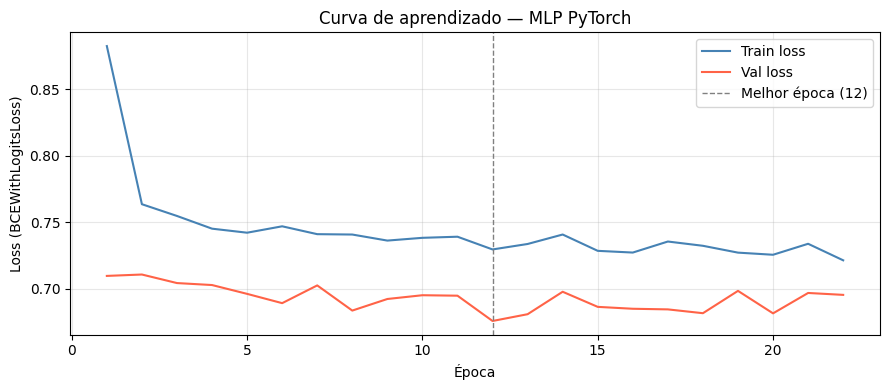

2026-04-23 23:30:09 | INFO     | etapa2_notebook | Curva salva. Melhor val_loss: 0.6758 na época 12


INFO:etapa2_notebook:Curva salva. Melhor val_loss: 0.6758 na época 12


In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs_axis = range(1, epochs_run + 1)

ax.plot(epochs_axis, history["train_loss"], label="Train loss", color="steelblue", linewidth=1.5)
ax.plot(epochs_axis, history["val_loss"],   label="Val loss",   color="tomato",    linewidth=1.5)
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, label=f"Melhor época ({best_epoch})")

ax.set_xlabel("Época")
ax.set_ylabel("Loss (BCEWithLogitsLoss)")
ax.set_title("Curva de aprendizado — MLP PyTorch")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()

logger.info("Curva salva. Melhor val_loss: %.4f na época %d", min(history["val_loss"]), best_epoch)

---
## Célula 7 — Random Forest como baseline de ensemble

**Requisito PDF:** *Comparar MLP vs baselines (lineares + árvores) usando ≥ 4 métricas.*

O Random Forest é um **ensemble de árvores de decisão**:  
treina N árvores em subconjuntos aleatórios dos dados e faz votação majoritária.  

Usado como baseline robusto porque:
- Não precisa de normalização de features (invariante a escala)
- Lida bem com dados tabulares sem muito ajuste
- `class_weight='balanced'` equivale ao `pos_weight` do PyTorch — trata o desbalanceamento

In [13]:
logger.info("Treinando Random Forest (baseline de ensemble)...")

rf_model = RandomForestClassifier(
    n_estimators=200,         # número de árvores — mais árvores = mais estável, mais lento
    max_depth=None,           # árvores crescem até pureza total (controlado por min_samples)
    class_weight="balanced",  # ajusta pesos inversamente proporcional à frequência de cada classe
    random_state=SEED,        # seed para reprodutibilidade
    n_jobs=-1,                # usa todos os cores disponíveis
)
# Usamos X_train_t (escalonado) para manter comparação justa com a MLP
# (RF não precisa disso, mas assim ambos recebem exatamente a mesma entrada)
rf_model.fit(X_train_t, y_train_arr)

logger.info("Random Forest treinado com %d árvores.", rf_model.n_estimators)

2026-04-23 23:30:13 | INFO     | etapa2_notebook | Treinando Random Forest (baseline de ensemble)...


INFO:etapa2_notebook:Treinando Random Forest (baseline de ensemble)...


2026-04-23 23:30:13 | INFO     | etapa2_notebook | Random Forest treinado com 200 árvores.


INFO:etapa2_notebook:Random Forest treinado com 200 árvores.


---
## Célula 8 — Avaliação com ≥ 4 métricas e registro no MLflow

**Requisito PDF:** *Comparar MLP vs baselines usando ≥ 4 métricas.*  
**Requisito PDF:** *Registrar todos os experimentos (MLP e ensembles) no MLflow.*

### Por que 4 métricas?
- **Accuracy:** fácil de interpretar, mas enganosa em dados desbalanceados
- **F1-Score:** equilíbrio entre precision e recall — boa para classes desbalanceadas
- **AUC-ROC:** mede separabilidade entre classes — independe do threshold
- **PR-AUC:** mais informativa que AUC-ROC quando a classe positiva é minoria

In [14]:
def evaluate(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    """Calcula as 4 métricas obrigatórias do Tech Challenge."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_score": float(f1_score(y_true, y_pred)),
        "roc_auc":  float(roc_auc_score(y_true, y_prob)),
        "pr_auc":   float(average_precision_score(y_true, y_prob)),
    }


# --- Predições MLP ---
# sigmoid converte logit → probabilidade [0,1]
with torch.no_grad():
    logits     = model(torch.tensor(X_test_t).to(device))
    y_prob_mlp = torch.sigmoid(logits).cpu().numpy().squeeze()
y_pred_mlp  = (y_prob_mlp >= 0.5).astype(int)
mlp_metrics = evaluate(y_test_arr, y_prob_mlp)

# --- Predições Random Forest ---
y_prob_rf  = rf_model.predict_proba(X_test_t)[:, 1]  # coluna 1 = probabilidade da classe positiva
y_pred_rf  = rf_model.predict(X_test_t)
rf_metrics = evaluate(y_test_arr, y_prob_rf)

# --- Tabela comparativa (entregável obrigatório da Etapa 2) ---
comparison = pd.DataFrame(
    {"MLP PyTorch": mlp_metrics, "Random Forest": rf_metrics}
).T.round(4)
print("\n=== Tabela comparativa de modelos (Etapa 2 — entregável obrigatório) ===")
print(comparison.to_string())

# --- MLflow: registra parâmetros + métricas + artefatos ---
# Requisito: registrar TODOS os experimentos (MLP e ensembles)
mlflow.set_experiment("Telco_Churn_Etapa2")

with mlflow.start_run(run_name="PyTorch_MLP"):
    mlflow.log_params({
        "architecture":            "64-32-16-1",
        "activation":              "ReLU",
        "loss_function":           "BCEWithLogitsLoss",
        "dropout":                 0.3,
        "epochs_run":              epochs_run,
        "best_epoch":              best_epoch,
        "batch_size":              BATCH_SIZE,
        "pos_weight":              round(pos_weight_value, 3),
        "optimizer":               "Adam",
        "lr":                      1e-3,
        "early_stopping_patience": 10,
        "seed":                    SEED,
    })
    mlflow.log_metrics(mlp_metrics)
    mlflow.log_metric("best_val_loss", min(history["val_loss"]))
    mlflow.pytorch.log_model(model, artifact_path="mlp_model")  # salva modelo para reuso
    mlflow.log_artifact("learning_curve.png")
    logger.info("MLP registrado no MLflow.")

with mlflow.start_run(run_name="RandomForest_Ensemble"):
    mlflow.log_params({
        "n_estimators": 200,
        "class_weight": "balanced",
        "max_depth":    "None",
        "seed":         SEED,
    })
    mlflow.log_metrics(rf_metrics)
    mlflow.sklearn.log_model(rf_model, artifact_path="rf_model")
    logger.info("Random Forest registrado no MLflow.")


=== Tabela comparativa de modelos (Etapa 2 — entregável obrigatório) ===
               accuracy  f1_score  roc_auc  pr_auc
MLP PyTorch      0.7282    0.6120   0.8398   0.627
Random Forest    0.7601    0.4955   0.8011   0.577


2026/04/23 23:30:58 INFO mlflow.tracking.fluent: Experiment with name 'Telco_Churn_Etapa2' does not exist. Creating a new experiment.
2026/04/23 23:30:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 23:30:58 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


2026-04-23 23:31:08 | INFO     | etapa2_notebook | MLP registrado no MLflow.


INFO:etapa2_notebook:MLP registrado no MLflow.
2026/04/23 23:31:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 23:31:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-23 23:31:12 | INFO     | etapa2_notebook | Random Forest registrado no MLflow.


INFO:etapa2_notebook:Random Forest registrado no MLflow.


---
## Célula 9 — Curvas ROC e Precision-Recall

**Requisito PDF:** *Comparar MLP vs baselines usando ≥ 4 métricas.*

- **Curva ROC:** quanto mais a curva se aproxima do canto superior esquerdo, melhor. AUC = área sob a curva.
- **Curva PR:** mais relevante para datasets desbalanceados. A linha pontilhada é o baseline aleatório (= taxa de churn do dataset).

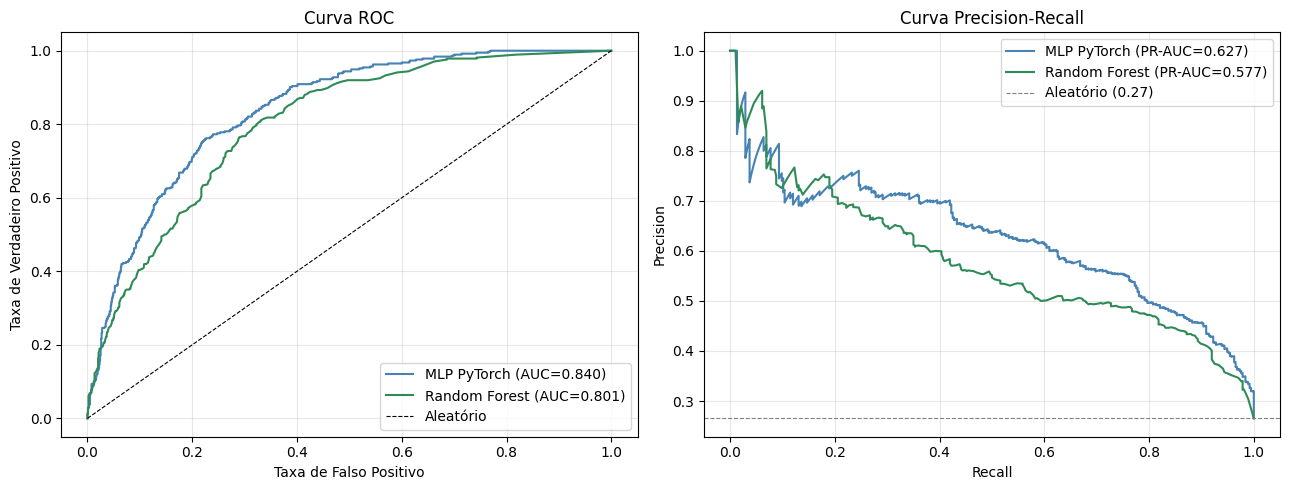

2026-04-23 23:31:12 | INFO     | etapa2_notebook | Curvas ROC e PR salvas.


INFO:etapa2_notebook:Curvas ROC e PR salvas.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_to_plot = [
    ("MLP PyTorch",   y_prob_mlp, "steelblue"),
    ("Random Forest", y_prob_rf,  "seagreen"),
]

# Curva ROC
for name, y_prob, color in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test_arr, y_prob)
    auc = roc_auc_score(y_test_arr, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aleatório")
axes[0].set_xlabel("Taxa de Falso Positivo")
axes[0].set_ylabel("Taxa de Verdadeiro Positivo")
axes[0].set_title("Curva ROC")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Curva Precision-Recall
for name, y_prob, color in models_to_plot:
    prec, rec, _ = precision_recall_curve(y_test_arr, y_prob)
    pr_auc = average_precision_score(y_test_arr, y_prob)
    axes[1].plot(rec, prec, label=f"{name} (PR-AUC={pr_auc:.3f})", color=color)
baseline_pr = y_test_arr.mean()  # um modelo aleatório acerta na proporção da classe positiva
axes[1].axhline(baseline_pr, color="gray", linestyle="--", linewidth=0.8,
                label=f"Aleatório ({baseline_pr:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=120, bbox_inches="tight")
plt.show()
logger.info("Curvas ROC e PR salvas.")

---
## Célula 10 — Matrizes de Confusão

Cada célula da matriz mostra contagem + percentual do total.  
**Foco no quadrante inferior esquerdo:** Falsos Negativos — clientes que vão cancelar  
mas o modelo previu que ficariam. Este é o erro mais caro para o negócio.

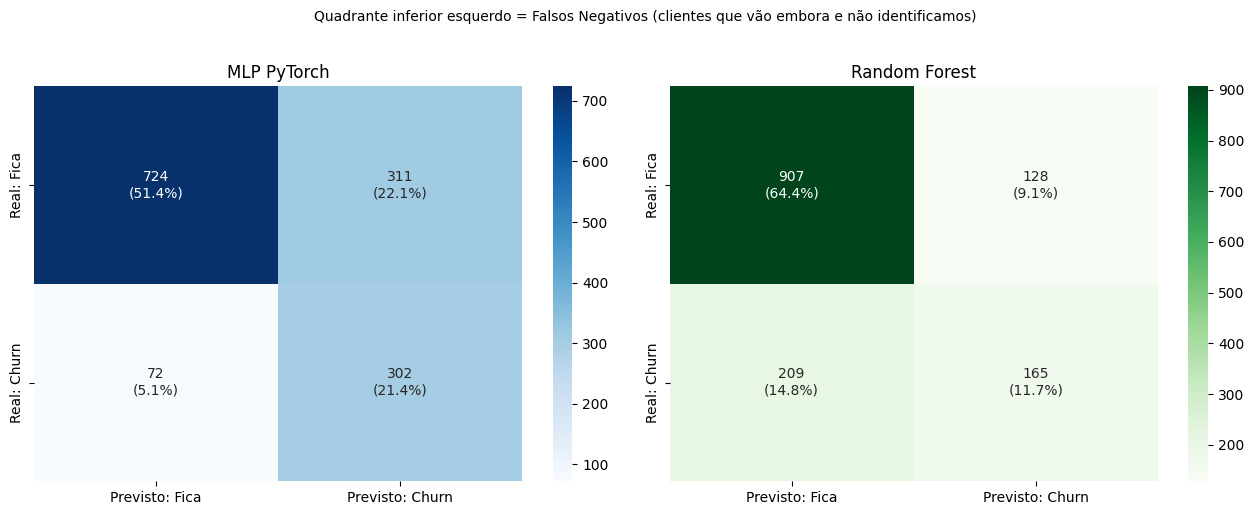

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_mlp, "MLP PyTorch",   "Blues"),
    (axes[1], y_pred_rf,  "Random Forest", "Greens"),
]:
    cm = confusion_matrix(y_test_arr, y_pred)
    # Anotação: contagem + percentual do total
    labels = [[f"{v}\n({v / cm.sum() * 100:.1f}%)" for v in row] for row in cm]
    sns.heatmap(
        cm, annot=labels, fmt="", cmap=cmap, ax=ax,
        xticklabels=["Previsto: Fica", "Previsto: Churn"],
        yticklabels=["Real: Fica", "Real: Churn"],
    )
    ax.set_title(title)

plt.suptitle(
    "Quadrante inferior esquerdo = Falsos Negativos (clientes que vão embora e não identificamos)",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Célula 11 — Análise de trade-off de custo de negócio

**Requisito PDF:** *Analisar trade-off de custo (falso positivo vs negativo).*

A matriz de confusão mostra contagens, mas o negócio pensa em **R$**.  
Aqui traduzimos os erros do modelo em impacto financeiro real para a operadora.

**Premissas:**
- **Custo FP (R$ 50):** oferta de retenção desnecessária para um cliente que não ia sair
- **Custo FN (R$ 500):** perda de um cliente que foi embora sem intervenção

Esses valores são ajustáveis — o modelo de negócio da operadora define os reais custos.

In [17]:
CUSTO_FP = 50.0   # R$ — custo de ação de retenção desnecessária
CUSTO_FN = 500.0  # R$ — custo de perder um cliente (receita futura perdida)


def custo_total(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    custo_fp: float,
    custo_fn: float,
) -> dict:
    """Calcula custo total de negócio com base nos erros do modelo."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()  # desempacota: TN=fica correto, FP=erramos fica, FN=erramos churn, TP=churn correto
    total_cost  = fp * custo_fp + fn * custo_fn
    recall_churn = tp / max(tp + fn, 1)  # % de churn real que o modelo identificou
    return {
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "Custo FP (R$)":      fp * custo_fp,
        "Custo FN (R$)":      fn * custo_fn,
        "Custo Total (R$)":   total_cost,
        "Churn detectado (%)": round(recall_churn * 100, 1),
    }


cost_mlp = custo_total(y_test_arr, y_pred_mlp, CUSTO_FP, CUSTO_FN)
cost_rf  = custo_total(y_test_arr, y_pred_rf,  CUSTO_FP, CUSTO_FN)

cost_df = pd.DataFrame({"MLP PyTorch": cost_mlp, "Random Forest": cost_rf}).T
print("\n=== Análise de Custo de Negócio ===")
print(f"Premissas: Custo FP = R${CUSTO_FP:.0f} | Custo FN = R${CUSTO_FN:.0f}")
print(cost_df.to_string())

melhor  = "MLP PyTorch" if cost_mlp["Custo Total (R$)"] < cost_rf["Custo Total (R$)"] else "Random Forest"
economia = abs(cost_mlp["Custo Total (R$)"] - cost_rf["Custo Total (R$)"])

logger.info("Melhor modelo por custo: %s | Economia: R$%.0f", melhor, economia)
print(f"\n>>> Melhor modelo por custo de negócio: {melhor}")
print(f">>> Economia potencial: R${economia:,.0f} em relação ao outro modelo")
print("\n>>> Dica: threshold=0.35 aumenta recall (menos FN) ao custo de mais FP")
print("    ajuste conforme a tolerância da operadora ao custo de cada tipo de erro")


=== Análise de Custo de Negócio ===
Premissas: Custo FP = R$50 | Custo FN = R$500
                  TP     TN     FP     FN  Custo FP (R$)  Custo FN (R$)  Custo Total (R$)  Churn detectado (%)
MLP PyTorch    302.0  724.0  311.0   72.0        15550.0        36000.0           51550.0                 80.7
Random Forest  165.0  907.0  128.0  209.0         6400.0       104500.0          110900.0                 44.1
2026-04-23 23:31:46 | INFO     | etapa2_notebook | Melhor modelo por custo: MLP PyTorch | Economia: R$59350


INFO:etapa2_notebook:Melhor modelo por custo: MLP PyTorch | Economia: R$59350



>>> Melhor modelo por custo de negócio: MLP PyTorch
>>> Economia potencial: R$59,350 em relação ao outro modelo

>>> Dica: threshold=0.35 aumenta recall (menos FN) ao custo de mais FP
    ajuste conforme a tolerância da operadora ao custo de cada tipo de erro


---
## Célula 12 — Resumo final da Etapa 2

**Entregável desta etapa:**
-  Tabela comparativa de modelos
-  MLP treinado com early stopping e `pos_weight`
-  Artefatos registrados no MLflow (modelos + imagens)
-  Análise de custo FP vs FN

In [18]:
print("=" * 55)
print("RESUMO — ETAPA 2")
print("=" * 55)

print(f"\nMLP PyTorch (arquitetura: input → 64 → 32 → 16 → 1)")
print(f"  Épocas rodadas : {epochs_run} | Melhor época: {best_epoch}")
print(f"  Melhor val_loss: {min(history['val_loss']):.4f}")
for k, v in mlp_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

print(f"\nRandom Forest (200 árvores, class_weight=balanced)")
for k, v in rf_metrics.items():
    print(f"  {k:12s}: {v:.4f}")

print("\nArtefatos gerados:")
print("  - learning_curve.png    (curva de aprendizado)")
print("  - roc_pr_curves.png     (curvas ROC e PR)")
print("  - confusion_matrices.png (matrizes de confusão)")
print("  - Modelos no MLflow → rode: mlflow ui --port 5000")

print("\nPróximos passos (Etapa 3):")
print("  - Refatorar código em src/models/mlp.py")
print("  - Construir API FastAPI com /predict e /health")
print("  - Escrever testes pytest (smoke, schema, API)")
print("  - Configurar ruff e Makefile")

logger.info("Etapa 2 concluída com sucesso.")

RESUMO — ETAPA 2

MLP PyTorch (arquitetura: input → 64 → 32 → 16 → 1)
  Épocas rodadas : 22 | Melhor época: 12
  Melhor val_loss: 0.6758
  accuracy    : 0.7282
  f1_score    : 0.6120
  roc_auc     : 0.8398
  pr_auc      : 0.6270

Random Forest (200 árvores, class_weight=balanced)
  accuracy    : 0.7601
  f1_score    : 0.4955
  roc_auc     : 0.8011
  pr_auc      : 0.5770

Artefatos gerados:
  - learning_curve.png    (curva de aprendizado)
  - roc_pr_curves.png     (curvas ROC e PR)
  - confusion_matrices.png (matrizes de confusão)
  - Modelos no MLflow → rode: mlflow ui --port 5000

Próximos passos (Etapa 3):
  - Refatorar código em src/models/mlp.py
  - Construir API FastAPI com /predict e /health
  - Escrever testes pytest (smoke, schema, API)
  - Configurar ruff e Makefile
2026-04-23 23:31:52 | INFO     | etapa2_notebook | Etapa 2 concluída com sucesso.


INFO:etapa2_notebook:Etapa 2 concluída com sucesso.
